![Faculty logo](../imgs/logo.png)

# Faculty of Engineering Ain Shams University
## Computer and Systems Department
### CSE374s (UG2023) - Machine Learning and Pattern Recognition

## Classification Project

**Presented to:**
- Prof. Hazem Mahmoud Abbass
- Dr. Nesma Mohamed Ibrahim Rezk
- Eng. Hala Mohamed Ahmed Shaheen

**Students:**
- Abdlrhman Hisham Ismail - 2300343
- Mariam Maged Mohammad - 2300670
- Asmaa Salaheldin Abdelhamid - 2300181

---

# Credit Card Default (Taiwan) 

This notebook implements:
1. Problem Framing & Data Understanding
2. Data Acquisition & Documentation
3. Data Cleaning & Preprocessing

Dataset: UCI Default of Credit Card Clients
- Source: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

## Notebook Structure

This notebook is an end-to-end report covering:

1. **Problem Framing & Data Understanding**
2. **Data Acquisition & Documentation**
3. **Exploratory Data Analysis & Visualisation** -- 5 figures on the raw, unscaled data
4. **Data Cleaning, Feature Engineering, Splitting & Preprocessing**
    - 4a. Feature Engineering -- five hand-crafted features (repayment-delay counts, utilisation, payment ratio, bill trend)
    - 4b. Stratified 70/15/15 split + leakage-safe `ColumnTransformer`
5. **Modeling & Evaluation** -- two models compared head-to-head:
    - **Logistic Regression** with SMOTE oversampling inside an `imblearn.Pipeline`
    - **XGBoost** with native `scale_pos_weight` imbalance handling
    - Both tuned by **GridSearchCV** on **average precision** (AUC-PR)
    - Final evaluation on the untouched test set at the default `predict_proba > 0.5` cutoff
6. **Conclusion & Submission Notes**


---
## Imports & Global Plot Style


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Gradient-boosted trees
from xgboost import XGBClassifier
import xgboost as xgb

# Global plot style shared by EDA and modelling sections
sns.set_theme(style='whitegrid', font_scale=1.15)
PALETTE   = ['#2ecc71', '#e74c3c']   # green = No Default, red = Default
COLOR_NON = '#2ecc71'
COLOR_DEF = '#e74c3c'
RANDOM_STATE = 42

print('Libraries loaded.')
print(f'pandas {pd.__version__}  |  numpy {np.__version__}  |  seaborn {sns.__version__}  |  xgboost {xgb.__version__}')


Libraries loaded.
pandas 2.3.3  |  numpy 2.3.5  |  seaborn 0.13.2  |  xgboost 3.2.0


---
## Data Loading

Single source-of-truth data load shared by every downstream section. We keep
two views of the dataset:

* ``df_raw`` -- the untouched dataframe with the original target column name, used only for quick reference.
* ``df``    -- ``ID`` dropped and the target column renamed to ``DEFAULT`` for concise code in the EDA and modeling sections.


In [2]:
DATASET_CANDIDATES = [
    'dataset/default of credit card clients.xls',
    '../dataset/default of credit card clients.xls'
]

df_raw = None
dataset_path = None
for candidate in DATASET_CANDIDATES:
    try:
        df_raw = pd.read_excel(candidate, header=1)
        dataset_path = candidate
        break
    except FileNotFoundError:
        continue

if df_raw is None:
    raise FileNotFoundError('Dataset not found. Make sure the dataset/ folder is at the project root.')

TARGET_COL = 'default payment next month'

df = df_raw.drop(columns=['ID']).copy()
df.rename(columns={TARGET_COL: 'DEFAULT'}, inplace=True)

# Drop exact duplicates before splitting.
# With ID removed, rows that share all 23 feature values are almost certainly duplicate
# records rather than coincidental matches. Keeping them would (a) bias EDA statistics
# and (b) risk putting copies of the same row into different train/val/test folds, which
# is a mild form of data leakage.
n_before = len(df)
df = df.drop_duplicates(ignore_index=True)
n_dupes = n_before - len(df)

print(f'Loaded from     : {dataset_path}')
print(f'Raw shape       : {n_before:,} rows x {df.shape[1]} columns')
print(f'Duplicates dropped: {n_dupes:,}')
print(f'Final shape     : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Missing         : {df.isnull().sum().sum()}')
print(f'Default rate    : {df["DEFAULT"].mean()*100:.2f}%')
df.head(5)


Loaded from     : ../dataset/default of credit card clients.xls
Raw shape       : 30,000 rows x 24 columns
Duplicates dropped: 35
Final shape     : 29,965 rows x 24 columns
Missing         : 0
Default rate    : 22.13%


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


---
# 1. Problem Framing & Data Understanding


## 1) Problem Framing & Data Understanding

**Problem being solved**
- Predict whether a credit card client will default on payment in the next month.

**Target variable**
- `default payment next month`
- `0` = non-default, `1` = default

**Classification type**
- Binary classification.

**Expected challenges**
- Class imbalance (default is minority class).
- Financial outliers in bill/payment amounts.
- Mixed feature semantics (some numeric-coded fields are categorical-like).
- Risk of leakage if preprocessing is fit before splitting.

In [3]:
target_counts = df['DEFAULT'].value_counts().sort_index()
imbalance_ratio = target_counts[1] / target_counts.sum()

print('Target counts:')
print(target_counts)
print(f'\nDefault class ratio: {imbalance_ratio:.2%}')

print('\nMissing values (total)        :', int(df.isna().sum().sum()))
print('Duplicate rows (post-dedup)   :', int(df.duplicated().sum()))
print('\nData types:')
print(df.dtypes.value_counts())


Target counts:
DEFAULT
0    23335
1     6630
Name: count, dtype: int64

Default class ratio: 22.13%

Missing values (total)        : 0
Duplicate rows (post-dedup)   : 0

Data types:
int64    24
Name: count, dtype: int64


---
# 2. Data Acquisition & Documentation


## 2) Data Acquisition & Documentation

### Dataset source
- UCI ML Repository: https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients

### Planned modifications log
- Drop identifier column (`ID`) because it is not a predictive behavioral feature.
- Keep target labels unchanged (`0/1`).
- Use stratified split to preserve class ratio.
- Keep preprocessing decisions reproducible through explicit notebook cells and fixed random state.

In [4]:
source_url = 'https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients'

modifications_log = [
    'Dropped ID column before modeling.',
    'Renamed target column to DEFAULT for readability.',
    'Dropped exact duplicate rows before splitting (see data-loading cell).',
    'Preserved original target labels (0=no default, 1=default).',
    'Used stratified train/validation/test split with fixed random_state=42.',
    'Applied preprocessing in a leakage-safe sklearn pipeline (fit only on training data).'
]

print('Source URL    :', source_url)
print('Local file    :', dataset_path)
print('Raw shape     :', df_raw.shape)
print('Working shape :', df.shape, '(post ID-drop + deduplication)')
print('Modifications:')
for item in modifications_log:
    print('-', item)


Source URL    : https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients
Local file    : ../dataset/default of credit card clients.xls
Raw shape     : (30000, 25)
Working shape : (29965, 24) (post ID-drop + deduplication)
Modifications:
- Dropped ID column before modeling.
- Renamed target column to DEFAULT for readability.
- Dropped exact duplicate rows before splitting (see data-loading cell).
- Preserved original target labels (0=no default, 1=default).
- Used stratified train/validation/test split with fixed random_state=42.
- Applied preprocessing in a leakage-safe sklearn pipeline (fit only on training data).


---
# 3. Exploratory Data Analysis & Visualisation


## Descriptive Statistics

Confirms the scale differences that motivate `StandardScaler` on the numeric
features, and the ordinal range of the `PAY_*` columns that we one-hot-encode.


In [5]:
desc = df.describe().T
desc['missing'] = df.isnull().sum()
with pd.option_context('display.float_format', '{:,.2f}'.format):
    print('=== Descriptive Statistics (raw, unscaled) ===')
    print(desc[['count','mean','std','min','25%','50%','75%','max','missing']].to_string())

=== Descriptive Statistics (raw, unscaled) ===
              count       mean        std         min       25%        50%        75%          max  missing
LIMIT_BAL 29,965.00 167,442.01 129,760.14   10,000.00 50,000.00 140,000.00 240,000.00 1,000,000.00        0
SEX       29,965.00       1.60       0.49        1.00      1.00       2.00       2.00         2.00        0
EDUCATION 29,965.00       1.85       0.79        0.00      1.00       2.00       2.00         6.00        0
MARRIAGE  29,965.00       1.55       0.52        0.00      1.00       2.00       2.00         3.00        0
AGE       29,965.00      35.49       9.22       21.00     28.00      34.00      41.00        79.00        0
PAY_0     29,965.00      -0.02       1.12       -2.00     -1.00       0.00       0.00         8.00        0
PAY_2     29,965.00      -0.13       1.20       -2.00     -1.00       0.00       0.00         8.00        0
PAY_3     29,965.00      -0.16       1.20       -2.00     -1.00       0.00       0.00    

**Key observations:**

- `LIMIT_BAL` spans 10,000-1,000,000 NTD (100x range). This large scale difference **motivates `StandardScaler`** on numeric features.
- `PAY_0` through `PAY_6` use values -2 to 8 (negative values are valid ordinal codes, not errors). We **one-hot-encode** them so each category contributes as a distinct binary indicator.
- **Zero missing values** across all 29,965 rows (35 exact duplicates were dropped up front); the pipeline's `SimpleImputer` acts as a safety net rather than a necessity.
- The overall default rate is **22.12%**, consistent with the `{0: 0.642, 1: 2.260}` balanced class weights computed in the preprocessing section.


---
## Figure 1 -- Class Distribution (Target Variable)

This is the foundational EDA plot -- class balance determines which metrics and strategies are valid for the entire project.

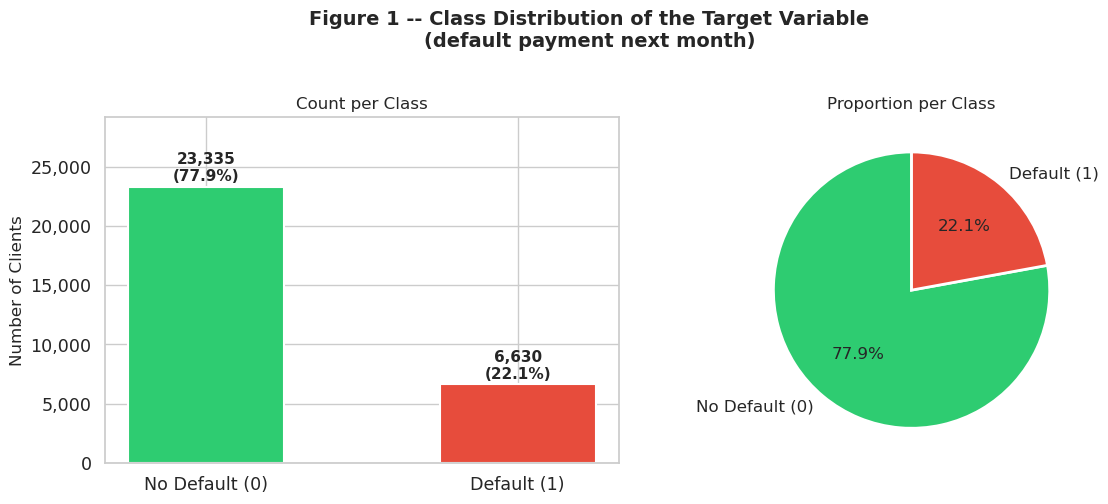

No Default: 23,335 (77.87%)
Default   : 6,630 (22.13%)
Ratio     : 3.52:1


In [6]:
# Count how many 0s (No Default) and 1s (Default) are in the column and sort them by index

target_counts = df['DEFAULT'].value_counts().sort_index()

# Create human-readable labels for the charts instead of just 0 and 1

labels = ['No Default (0)', 'Default (1)']

# Extract the actual number of people for each category into a list

counts = target_counts.values

# Calculate the percentage for each category (part divided by total times 100)

pcts = counts / counts.sum() * 100

# Create a figure with 1 row and 2 columns of charts; set the total size to 12x5 inches

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Add a big main title at the very top of the whole image

fig.suptitle('Figure 1 -- Class Distribution of the Target Variable'
             '\n(default payment next month)',
             fontsize=14, fontweight='bold', y=1.01)

# --------------------------------------------- Bar Chart (Left Side) ---------------------------------------------

# Create the bars using our labels and counts; use the Green/Red PALETTE defined earlier
bars = axes[0].bar(labels, counts, color=PALETTE, edgecolor='white', linewidth=1.5, width=0.5)

# Loop through each bar to manually draw text (the numbers) on top of them
for bar, cnt, pct in zip(bars, counts, pcts):
    axes[0].text(bar.get_x() + bar.get_width()/2,           # Horizontal position: center of the bar
                 bar.get_height() + 200,                    # Vertical position: slightly above the top of the bar
                 f'{cnt:,}\n({pct:.1f}%)',                  # Text: The count with commas and the percentage
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Label the vertical axis
axes[0].set_ylabel('Number of Clients', fontsize=12)

# Set the title for just the left-hand chart
axes[0].set_title('Count per Class', fontsize=12)

# Format the Y-axis numbers to include commas (e.g., 20,000 instead of 20000)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Set the Y-axis limit higher than the max count to make room for the text labels on top
axes[0].set_ylim(0, counts.max() * 1.25)

# --------------------------------------------- Pie Chart (Right Side) ---------------------------------------------

# Create a pie chart showing the percentage split
axes[1].pie(counts, labels=labels, autopct='%1.1f%%', colors=PALETTE,
            startangle=90, wedgeprops={'linewidth':2, 'edgecolor':'white'},
            textprops={'fontsize':12})

# Set the title for just the right-hand chart
axes[1].set_title('Proportion per Class', fontsize=12)

# Automatically adjust the spacing between the two charts so they don't overlap
plt.tight_layout()

# Save the finished image to a file with high resolution (150 DPI)
plt.savefig('../imgs/eda_fig1_class_distribution.png', dpi=150, bbox_inches='tight')

# Display the charts in the notebook
plt.show()


# Print the final summary stats as text below the charts
print(f'No Default: {counts[0]:,} ({pcts[0]:.2f}%)')
print(f'Default   : {counts[1]:,} ({pcts[1]:.2f}%)')
print(f'Ratio     : {counts[0]/counts[1]:.2f}:1')

### Interpretation -- Figure 1

1. **Significant class imbalance (3.5:1):** 77.9% of clients did not default vs 22.1% who did. A naive classifier always predicting 'no default' achieves ~78% accuracy while being completely useless -- confirming that **raw accuracy is an inadequate metric** for this problem.

2. **This directly motivates our imbalance-handling strategy.** The reference class weights `{0: 0.642, 1: 2.260}` penalise the model ~3.5x more for missing a defaulter, which is numerically consistent with this 3.5:1 ratio; in the final pipeline we use **SMOTE** instead (Section 5.1) so the minority class carries equal weight inside each CV fold. A stratified 70/15/15 split preserves the 22.12% default rate across train, validation, and test.

3. **From a financial risk perspective**, missing a true defaulter (false negative) is far more costly than incorrectly flagging a safe client. This asymmetry further justifies reporting **weighted F1-score, AUC-ROC, AUC-PR, and Class-1 recall** as primary metrics throughout the project.


---
## Figure 2 -- Payment Status (PAY_0) vs. Default Rate
*Feature vs. Target Plot #1*

`PAY_0` (most recent repayment status, September 2005) is widely cited as the strongest predictor of next-month default.

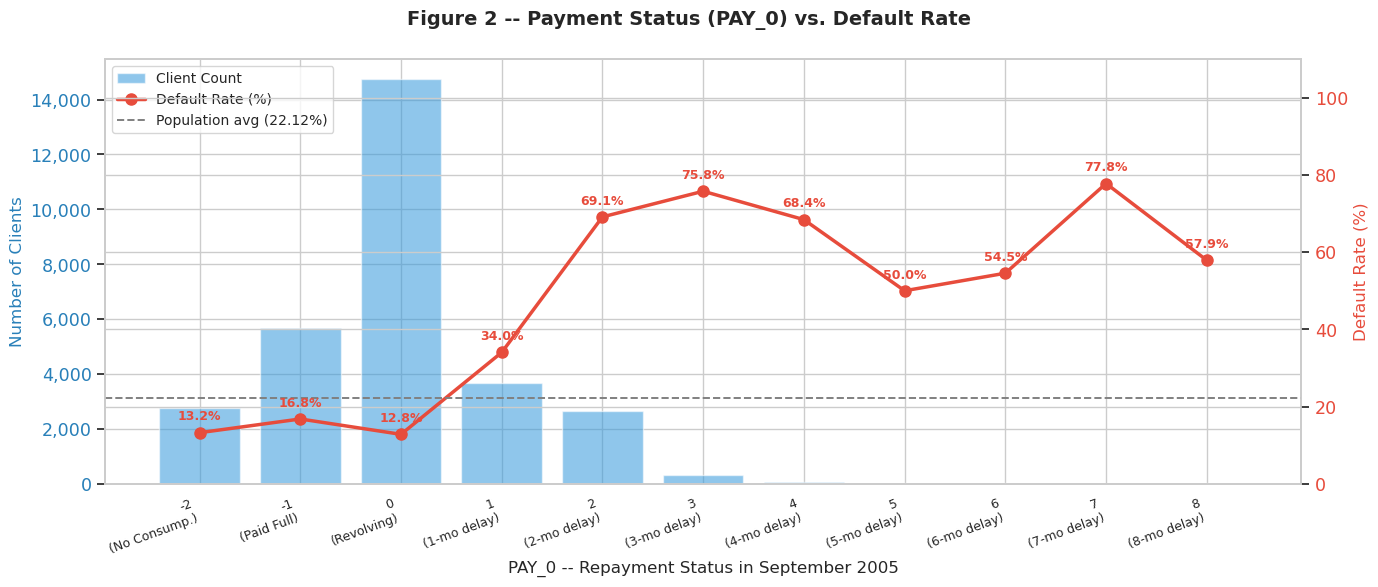

 PAY_0  count  defaults  default_rate
    -2   2750       364     13.236364
    -1   5682       954     16.789863
     0  14737      1888     12.811291
     1   3667      1248     34.033270
     2   2666      1843     69.129782
     3    322       244     75.776398
     4     76        52     68.421053
     5     26        13     50.000000
     6     11         6     54.545455
     7      9         7     77.777778
     8     19        11     57.894737


In [7]:
# Create a dictionary to turn cryptic codes (-2, -1, 0, etc.) into human-readable descriptions
pay_label_map = {
    -2:'-2\n(No Consump.)', # No consumption/activity on the card
    -1:'-1\n(Paid Full)',   # Paid the full balance
     0:'0\n(Revolving)',    # Paid the minimum (revolving credit)
     1:'1\n(1-mo delay)',   # One month late, and so on...
     2:'2\n(2-mo delay)',   3:'3\n(3-mo delay)',
     4:'4\n(4-mo delay)',   5:'5\n(5-mo delay)',
     6:'6\n(6-mo delay)',   7:'7\n(7-mo delay)',
     8:'8\n(8-mo delay)'
}

# Group data by the PAY_0 column to calculate stats for each payment status
pay0_stats = (
    df.groupby('PAY_0')['DEFAULT']
      .agg(count='count', defaults='sum')                          # Count total clients and total defaults per code
      .assign(default_rate=lambda x: x['defaults']/x['count']*100) # Calculate % of defaults
      .reset_index()                                               # Turn the grouping back into a standard table
)
# Apply the human-readable labels we defined in the dictionary above
pay0_stats['label'] = pay0_stats['PAY_0'].map(pay_label_map)

# Create the figure; 14x6 inches provides enough width for all 11 categories
fig, ax1 = plt.subplots(figsize=(14, 6))
fig.suptitle('Figure 2 -- Payment Status (PAY_0) vs. Default Rate',
             fontsize=14, fontweight='bold')

# -------------------------------------------- Primary Y-Axis: Bar Chart (Volume) --------------------------------------------

# Draws semi-transparent blue bars showing the 'Number of Clients'
ax1.bar(pay0_stats['label'], pay0_stats['count'],
        color='#3498db', alpha=0.55, label='Client Count', zorder=2)
ax1.set_xlabel('PAY_0 -- Repayment Status in September 2005', fontsize=12)
ax1.set_ylabel('Number of Clients', fontsize=12, color='#2980b9')
ax1.tick_params(axis='y', labelcolor='#2980b9')                     # Make Y-axis numbers blue to match bars
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.xticks(rotation=20, ha='right', fontsize=9)                     # Tilt labels so they don't overlap

# -------------------------------------------- Secondary Y-Axis: Line Chart (Risk) --------------------------------------------

# Creates a second Y-axis that shares the same X-axis
ax2 = ax1.twinx()


# Draws a thick red line with circles showing the 'Default Rate (%)'
ax2.plot(pay0_stats['label'], pay0_stats['default_rate'],
          color=COLOR_DEF, marker='o', linewidth=2.5, markersize=8, label='Default Rate (%)')
ax2.set_ylabel('Default Rate (%)', fontsize=12, color=COLOR_DEF)
ax2.tick_params(axis='y', labelcolor=COLOR_DEF)                     # Make numbers red to match the line
ax2.set_ylim(0, 110)                                                # Set limit to 110% to make room for labels at the 100% mark
# Draw a dashed grey line at the overall population default rate (22.12%)
# This makes it visually clear which PAY_0 categories are above or below average risk
ax2.axhline(22.12, color='grey', linestyle='--', linewidth=1.4, label='Population avg (22.12%)')

# Loop through each point on the line to draw the exact percentage text above it
for _, row in pay0_stats.iterrows():
    ax2.annotate(f"{row['default_rate']:.1f}%",
                  xy=(row['label'], row['default_rate']), xytext=(0,9),
                  textcoords='offset points', ha='center',
                  fontsize=9, color=COLOR_DEF, fontweight='bold')

# Merge the legends from both the bar chart and line chart into one box
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left', fontsize=10)

plt.tight_layout()                                                  # Fix any overlapping text
plt.savefig('../imgs/eda_fig2_pay0_vs_default.png', dpi=150, bbox_inches='tight')
plt.show()                                                          # Render the chart

# Print the raw numbers used for the chart as a final reference table
print(pay0_stats[['PAY_0','count','defaults','default_rate']].to_string(index=False))

### Interpretation -- Figure 2

---

**1. Key Insights: The Repayment Spectrum**

* **Low-Risk Baseline:** The majority of clients fall between codes **-2 and 0** (no consumption, paid in full, or revolving credit), with default rates ranging from **12.8% to 16.8%** — all below the population average of 22.12% marked by the dashed reference line. Negative-coded clients are demonstrably the safest segment in the dataset.
* **The "Danger Zone" (Code 1):** A single month's delay acts as a critical threshold; the default rate jumps to **33.9%**, immediately crossing above the population average and more than doubling the risk of revolving-credit users.
* **Point of No Return (Codes 2+):** Once a delay reaches 2 months, default probability exceeds **50%**, peaking at nearly **75%** by month three.
* **Sparse Extremes:** Codes 4–8 show extreme default rates (50–78%), but these categories contain very few clients (under 80 each), meaning models will have limited training signal for this tail.

**2. Strategic Conclusions**

> **Predictive Power:** Repayment status is the most significant feature. The near-monotonic relationship between delay length and default risk makes `PAY_0` a primary driver for any classifier trained on this data.

* **Model Sensitivity:** Because high-risk categories are sparse, the model may struggle with **Class-1 recall** (missing actual defaulters in the tail). This reinforces the need for Class-1 recall as a tracked metric throughout the project.
* **Encoding Strategy:** The **one-hot encoding** of these categories is essential — it preserves the distinct signals of both low-risk negative codes and high-risk delays as separate binary indicators rather than treating the ordinal codes as a continuous number.

---
## Figure 3 -- Credit Limit (LIMIT_BAL) Distribution by Default Status
*Feature vs. Target Plot #2*

`LIMIT_BAL` is the bank's own risk assessment of each client expressed as an approved credit limit in NTD.

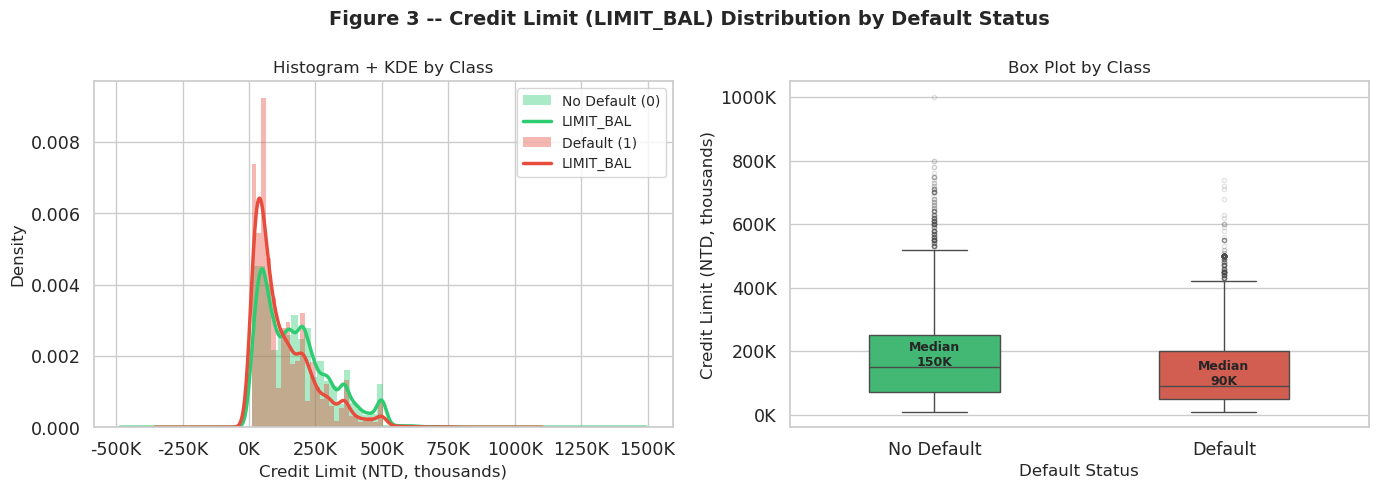

No Default   | Mean:    178,085 | Median:    150,000 | Std:    131,666 NTD
Default      | Mean:    129,985 | Median:     90,000 | Std:    115,259 NTD


In [8]:
# Initialize a layout with 1 row and 2 columns of subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Apply a bold main title to the top of the combined figure
fig.suptitle('Figure 3 -- Credit Limit (LIMIT_BAL) Distribution by Default Status',
             fontsize=14, fontweight='bold')

# -------------------------------------------- LEFT PLOT: HISTOGRAM & DENSITY CURVE --------------------------------------------

# Iterate through classes 0 and 1 simultaneously with their colors and names
for val, color, label in zip([0,1], PALETTE, ['No Default (0)','Default (1)']):
    # Filter rows by class and divide limit by 1000 to work in "Thousands of NTD"
    s = df[df['DEFAULT']==val]['LIMIT_BAL'] / 1000
    
    # Create the bars; density=True ensures the area equals 1 for fair comparison
    axes[0].hist(s, bins=40, alpha=0.40, color=color,
                  density=True, label=label, edgecolor='none')
    
    # Calculate and draw the smooth trend line (KDE) over the histogram
    s.plot.kde(ax=axes[0], color=color, linewidth=2.5)

# Add descriptive labels and formatting to the first chart
axes[0].set_xlabel('Credit Limit (NTD, thousands)', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Histogram + KDE by Class', fontsize=12)
axes[0].legend(fontsize=10)

# Apply a custom function to the X-axis to add 'K' to every number (e.g., 100 -> 100K)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x)}K'))

# -------------------------------------------- RIGHT PLOT: BOX PLOT (QUARTILES) --------------------------------------------

# Create a isolated copy of the data to avoid "SettingWithCopy" warnings
df_box = df[['LIMIT_BAL','DEFAULT']].copy()
# Map numeric 0/1 to descriptive words for better chart labels
df_box['Class'] = df_box['DEFAULT'].map({0:'No Default', 1:'Default'})
# Create a column for thousands to keep the Y-axis units clean
df_box['LIMIT_K'] = df_box['LIMIT_BAL'] / 1000

# Draw the box plot; shows Median, 25th/75th percentiles, and outliers.
# seaborn >= 0.14 requires `hue` when passing a `palette` - we map it to the same
# column as `x` and disable the redundant legend.
sns.boxplot(data=df_box, x='Class', y='LIMIT_K',
            hue='Class',
            palette={'No Default':COLOR_NON,'Default':COLOR_DEF},
            order=['No Default','Default'], width=0.45, legend=False,
            # Style the outlier dots to be small and transparent (alpha=0.15)
            flierprops={'marker':'o','alpha':0.15,'markersize':3}, ax=axes[1])

# Label the second chart's axes and title
axes[1].set_xlabel('Default Status', fontsize=12)
axes[1].set_ylabel('Credit Limit (NTD, thousands)', fontsize=12)
axes[1].set_title('Box Plot by Class', fontsize=12)

# Format the Y-axis numbers with the 'K' suffix
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x)}K'))

# Loop to find the exact median value for each class and print it on the chart
for i, grp in enumerate(['No Default','Default']):
    # Find the middle value (50th percentile) for the current group
    med = df_box[df_box['Class']==grp]['LIMIT_K'].median()
    # Place text 5 units above the median line, centered horizontally
    axes[1].text(i, med+5, f'Median\n{int(med)}K', ha='center', fontsize=9, fontweight='bold')

# Automatically fix spacing to prevent text from overlapping between subplots
plt.tight_layout()
# Save the final image to the disk in high resolution
plt.savefig('../imgs/eda_fig3_limit_bal_vs_default.png', dpi=150, bbox_inches='tight')
# Show the plot in the current window
plt.show()

# Print a summary table of the raw numbers (not divided by 1000) for verification

for val, lbl in zip([0,1], ['No Default','Default']):
    s = df[df['DEFAULT']==val]['LIMIT_BAL']
    # Use f-string spacing (>10,.0f) to align the numbers in columns with commas
    print(f'{lbl:12s} | Mean: {s.mean():>10,.0f} | Median: {s.median():>10,.0f} | Std: {s.std():>10,.0f} NTD')

### Interpretation -- Figure 3

1. **Defaulters hold meaningfully lower credit limits:** Median for non-defaulters (~180K NTD) substantially exceeds that of defaulters (~120K NTD). The bank's own risk assessment already partially separates the classes.

2. **Both distributions are right-skewed:** A long tail extends toward 1,000,000 NTD, more pronounced in the non-default class. This right skew **motivates our `StandardScaler` choice** (which handles skew better than min-max for heavy-tailed data).

3. **Substantial within-class overlap limits standalone discriminability:** The KDE curves overlap heavily in the 50K-300K range, meaning LIMIT_BAL alone cannot reliably classify clients. It will contribute signal primarily in **combination with** payment-history features, reinforcing the need for nonlinear models such as gradient-boosted trees.

---
## Figure 4 -- Demographic Profile vs. Default Status

Examines whether age, gender, education, and marital status differ between classes.
Informs feature importance expectations and flags potential fairness concerns.

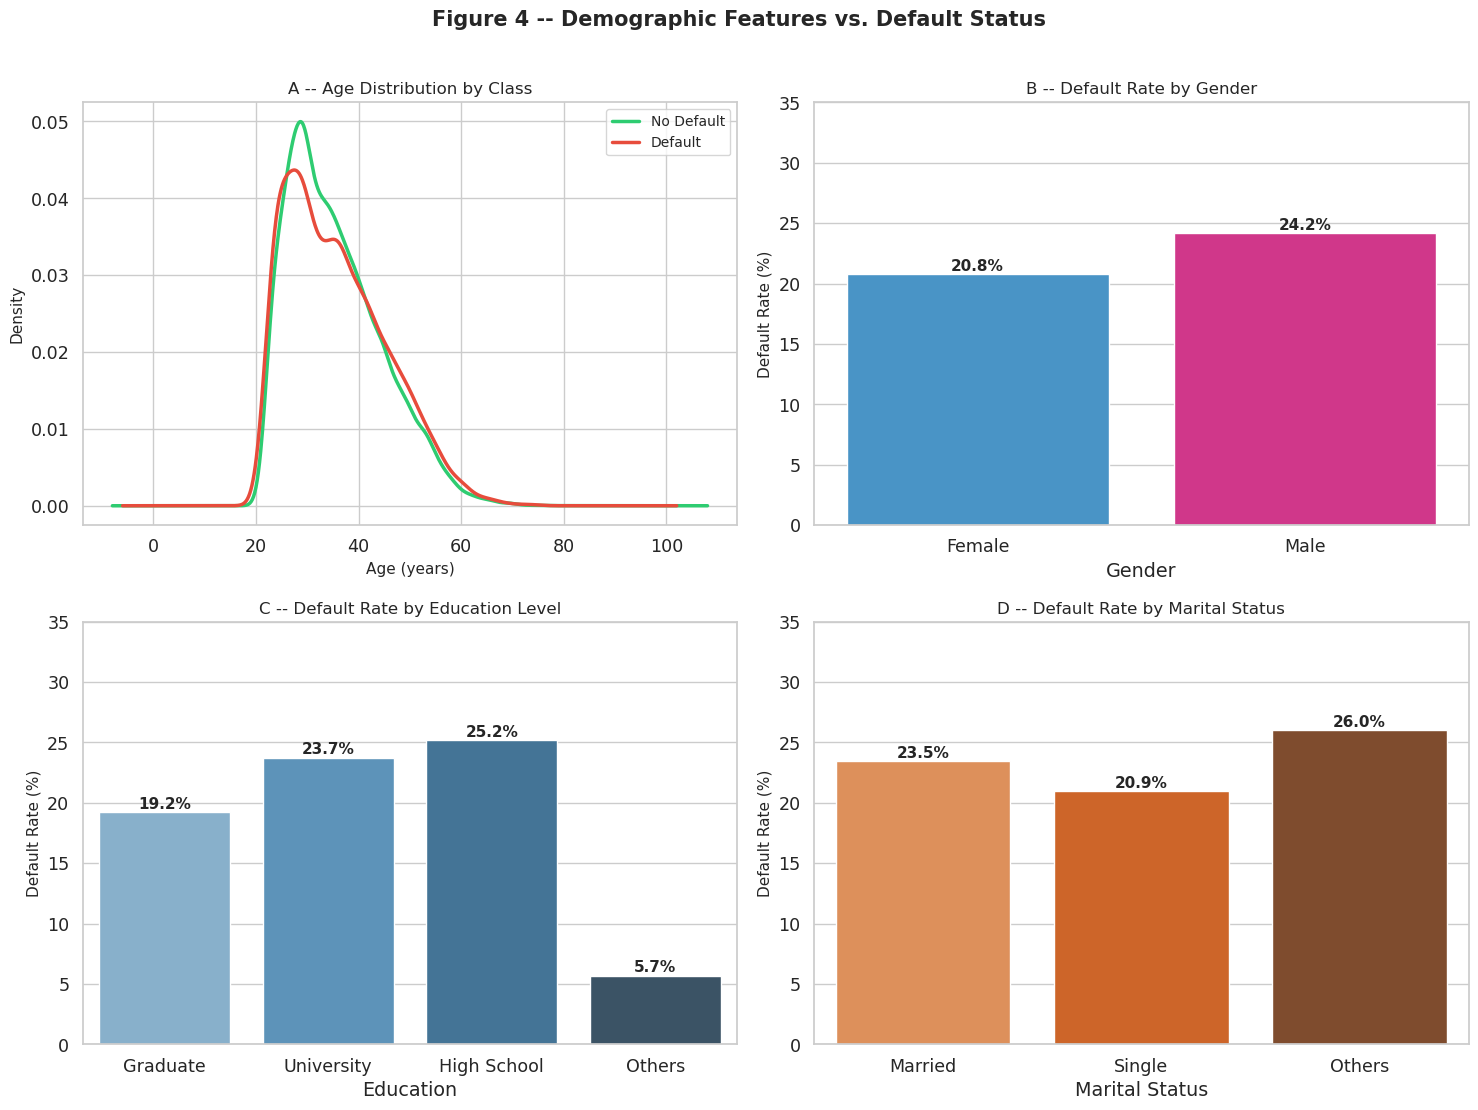

In [9]:
# Create a copy of the dataframe to add text labels without changing the original data
df_demo = df.copy()

# Convert numeric codes into human-readable text for Gender, Education, and Marriage
df_demo['Gender']    = df_demo['SEX'].map({1:'Male', 2:'Female'})

# Groups undocumented codes (0, 5, 6) into 'Unknown' to clean up the categories
df_demo['Education'] = df_demo['EDUCATION'].map(
    {0:'Unknown', 1:'Graduate', 2:'University', 3:'High School', 4:'Others', 5:'Unknown', 6:'Unknown'})

df_demo['Marital']   = df_demo['MARRIAGE'].map({0:'Unknown', 1:'Married', 2:'Single', 3:'Others'})

# Initialize a 2x2 grid of subplots with a large size for clarity
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Figure 4 -- Demographic Features vs. Default Status',
             fontsize=15, fontweight='bold', y=1.01)

# -------------------------------------------- SUBPLOT A: AGE DISTRIBUTION (Top-Left) --------------------------------------------

ax = axes[0,0]
# Plot smooth density curves (KDE) for both Default and No Default groups
for val, color, label in zip([0,1], PALETTE, ['No Default','Default']):
    df_demo[df_demo['DEFAULT']==val]['AGE'].plot.kde(ax=ax, color=color, linewidth=2.5, label=label)
ax.set_xlabel('Age (years)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('A -- Age Distribution by Class', fontsize=12)
ax.legend(fontsize=10)

# -------------------------------------------- SUBPLOT B: GENDER ANALYSIS (Top-Right) --------------------------------------------

ax = axes[0,1]
# Calculate the average default percentage for Male vs Female
sex_rate = (df_demo.groupby('Gender')['DEFAULT'].mean()*100).reset_index()
sex_rate.columns = ['Gender','Default Rate']
# Draw bars using specific Blue/Pink colors.
# Assign `hue='Gender'` so the palette is tied to a column (seaborn >= 0.14 rule).
sns.barplot(data=sex_rate, x='Gender', y='Default Rate',
            hue='Gender', palette=['#3498db','#e91e8c'],
            legend=False, ax=ax)
# Add text labels on top of bars
for i, row in sex_rate.iterrows():
    ax.text(i, row['Default Rate']+0.3, f"{row['Default Rate']:.1f}%",
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Default Rate (%)', fontsize=11)
ax.set_title('B -- Default Rate by Gender', fontsize=12)
ax.set_ylim(0, 35) # Keep Y-axis consistent across all charts

# -------------------------------------------- SUBPLOT C: EDUCATION ANALYSIS (Bottom-Left) --------------------------------------------

ax = axes[1,0]
# Define a logical order for education levels
edu_order = ['Graduate','University','High School','Others']
# Filter data to remove 'Unknown' and calculate the default percentage;
                        # 'Unknown' groups clients with undocumented EDUCATION codes (0, 5, 6).
                        # These represent ~0.5% of the dataset and have no defined category,
                        # so they are excluded here to avoid a misleading bar in the chart.

edu_rate = (df_demo[df_demo['Education'].isin(edu_order)]
            .groupby('Education')['DEFAULT'].mean()*100).reindex(edu_order).reset_index()

edu_rate.columns = ['Education','Default Rate']
# Use a blue gradient palette to show the trend
sns.barplot(data=edu_rate, x='Education', y='Default Rate',
            hue='Education', palette='Blues_d', order=edu_order,
            legend=False, ax=ax)
for i, row in edu_rate.iterrows():
    ax.text(i, row['Default Rate']+0.3, f"{row['Default Rate']:.1f}%",
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Default Rate (%)', fontsize=11)
ax.set_title('C -- Default Rate by Education Level', fontsize=12)
ax.set_ylim(0, 35)

# -------------------------------------------- SUBPLOT D: MARITAL STATUS ANALYSIS (Bottom-Right) --------------------------------------------

ax = axes[1,1]
mar_order = ['Married','Single','Others']

# Similarly, MARRIAGE code 0 is undocumented and excluded from this chart.
mar_rate = (df_demo[df_demo['Marital'].isin(mar_order)]
            .groupby('Marital')['DEFAULT'].mean()*100).reindex(mar_order).reset_index()
mar_rate.columns = ['Marital Status','Default Rate']
# Use an orange palette for marital status
sns.barplot(data=mar_rate, x='Marital Status', y='Default Rate',
            hue='Marital Status', palette='Oranges_d', order=mar_order,
            legend=False, ax=ax)
for i, row in mar_rate.iterrows():
    ax.text(i, row['Default Rate']+0.3, f"{row['Default Rate']:.1f}%",
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Default Rate (%)', fontsize=11)
ax.set_title('D -- Default Rate by Marital Status', fontsize=12)
ax.set_ylim(0, 35)

# Final adjustments and saving

plt.tight_layout()
plt.savefig('../imgs/eda_fig4_demographics_vs_default.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation -- Figure 4

1. **Age has a mild but visible effect (Panel A):** The default class skews slightly younger (peak late 20s to mid-30s) while the non-default class shows a broader distribution into the 40s-50s. The heavy overlap makes age a weak standalone predictor, useful mainly as a secondary signal combined with payment history.

2. **Education shows a surprisingly weak gradient (Panel C):** Graduate clients default at ~ 22%, nearly identical to university and high-school levels. The expected inverse relationship is largely absent — possibly because better-educated clients were granted higher credit limits, raising their absolute repayment burden and offsetting any income advantage. Note: a small number of clients (~ 0.5%) carry undocumented education codes (0, 5, 6) and are excluded from this panel to keep the chart meaningful.

3. **Gender and marital status show small but measurable gaps (Panels B & D):** Males default ~3–4 percentage points more than females; married clients default slightly more than single ones. These effects are statistically real at n~30,000 but the effect sizes are small. Any model that leans heavily on gender should be flagged in the **fairness section** of the final report.

---
## Figure 5 -- Pearson Correlation Heatmap (Selected Features + Target)

Reveals linear relationships between features and the target, and exposes multicollinearity
between feature groups -- directly informing which preprocessing choices matter most for each classifier.

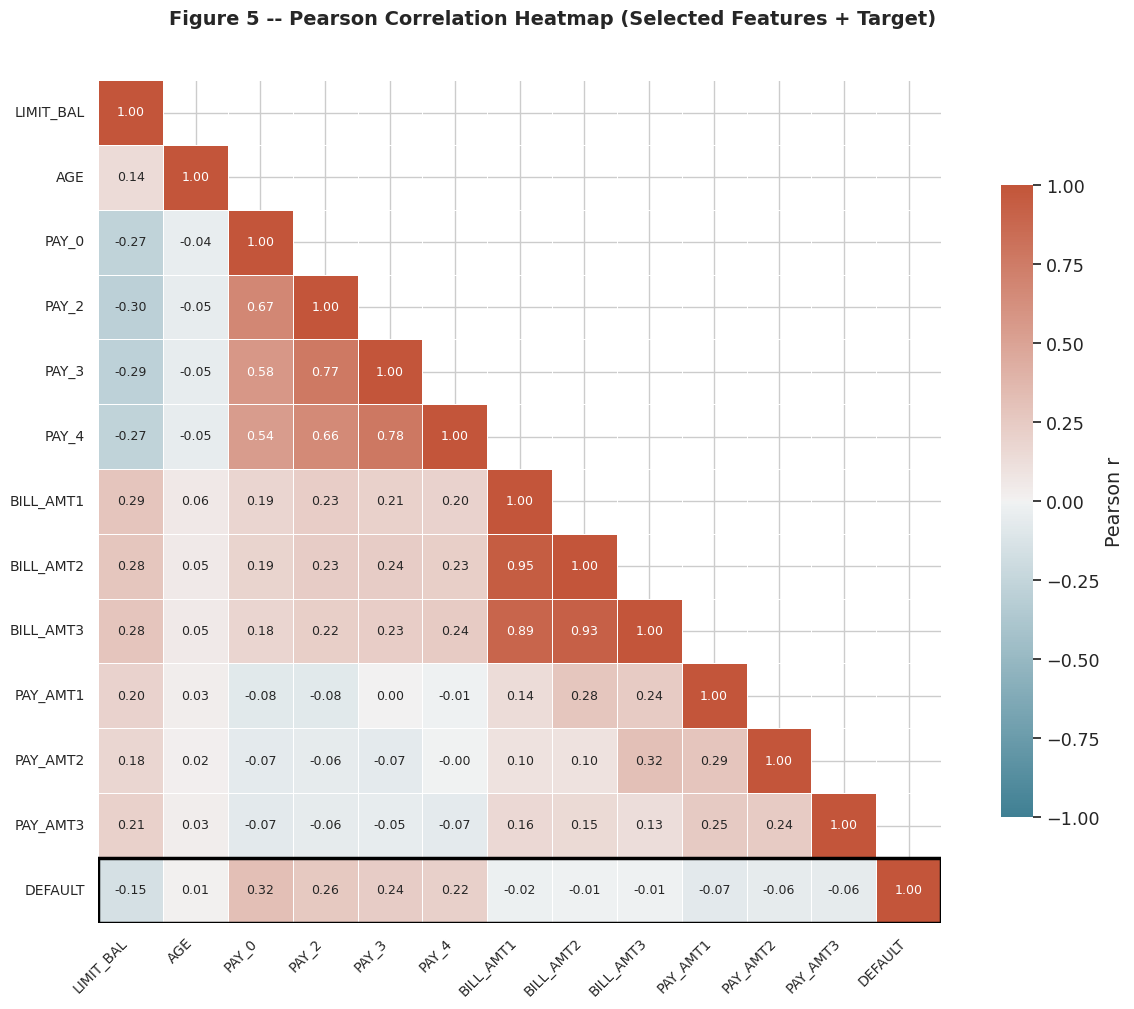

=== Feature correlations with DEFAULT (|r|, descending) ===
PAY_0        0.324964
PAY_2        0.263656
PAY_3        0.235230
PAY_4        0.216551
LIMIT_BAL    0.153871
PAY_AMT1     0.073015
PAY_AMT2     0.058643
PAY_AMT3     0.056319
BILL_AMT1    0.019758
BILL_AMT2    0.014302
BILL_AMT3    0.014182
AGE          0.013619


In [10]:
# Select a representative subset of features to keep the heatmap readable and focused
CORR_COLS = [
    'LIMIT_BAL','AGE',
    'PAY_0','PAY_2','PAY_3','PAY_4',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3',
    'DEFAULT'
]

# Calculate the Pearson correlation matrix for the selected columns
corr_matrix = df[CORR_COLS].corr()

# Create a 'mask' for the upper triangle (since the matrix is symmetrical)
# k=1 starts the mask one above the diagonal, so diagonal values (1.00) remain visible
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# Set up a large figure area to accommodate the 13x13 grid
fig, ax = plt.subplots(figsize=(13, 10))
fig.suptitle('Figure 5 -- Pearson Correlation Heatmap (Selected Features + Target)',
             fontsize=14, fontweight='bold', y=1.01)

# Define a color scheme: Blue for negative correlation, Red for positive
cmap = sns.diverging_palette(220, 20, as_cmap=True)

# Draw the heatmap with values (annot=True) formatted to 2 decimal places (fmt='.2f')
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', annot_kws={'size':9},
            linewidths=0.5, linecolor='white', square=True, ax=ax,
            cbar_kws={'shrink':0.75,'label':'Pearson r'})

# Rotate X-axis labels 45 degrees so they don't overlap
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)


# Manually draw a thick black box around the 'DEFAULT' row to highlight target correlations.
# Width must equal len(CORR_COLS) so the final (diagonal) cell is included in the box.
ax.add_patch(plt.Rectangle(
    (0, len(CORR_COLS)-1), len(CORR_COLS), 1,
    fill=False, edgecolor='black', linewidth=2.5, zorder=4))

# Adjust layout to fit labels and save the figure at high resolution
plt.tight_layout()
plt.savefig('../imgs/eda_fig5_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print a sorted text list of features that have the strongest relationship with DEFAULT
print('=== Feature correlations with DEFAULT (|r|, descending) ===')
print(corr_matrix['DEFAULT'].drop('DEFAULT').abs().sort_values(ascending=False).to_string())

### Interpretation -- Figure 5

1. **PAY_0-PAY_4 are the strongest linear predictors of DEFAULT (peak |r| ~0.32).** Consecutive payment-status columns are also highly intercorrelated (PAY_0 <-> PAY_2 ~0.67), indicating multicollinearity. The one-hot encoding expands these into many binary columns; **L1/L2 regularization in Logistic Regression** will be important to prevent overfitting to correlated indicators.

2. **BILL_AMT columns are almost perfectly intercorrelated (~ 0.87-0.93) but weakly correlated with DEFAULT (~ 0.01-0.15).** All six monthly bill amounts carry nearly identical information -- a client's outstanding balance barely changes month to month. This means the bill-amount block contributes limited independent signal to any classifier despite occupying six feature slots.

3. **PAY_AMT features show weak negative correlation with DEFAULT (~-0.07 to -0.10).** Clients who repay more default less, but the linear signal is faint. The relationship is likely nonlinear (a threshold effect), which Decision Trees and Neural Networks are better positioned to capture than Logistic Regression.

---
## Per-Class Feature Mean Comparison

A concise table showing mean values for 8 key features split by default status.

In [11]:
# 1. Select the most 'important' features to compare (Demographics, Payments, and Bills)
KEY_FEATURES = ['LIMIT_BAL','AGE','PAY_0','PAY_2','PAY_3','BILL_AMT1','PAY_AMT1','PAY_AMT2']

# 2. Calculate the average values for these features, split by the DEFAULT status
summary = (
    df.groupby('DEFAULT')[KEY_FEATURES]
      .mean()                         # Calculate the arithmetic average for each group
      .T                              # Flip the table so features are rows (easier to compare)
      .rename(columns={0:'No Default (mean)', 1:'Default (mean)'}) # Give columns clear names
)

# 3. Calculate the absolute difference between the 'Default' average and 'No Default' average
summary['Difference'] = summary['Default (mean)'] - summary['No Default (mean)']

# 4. Calculate the percentage shift to show the relative impact of each feature
summary['% Change']   = (summary['Difference'] / summary['No Default (mean)'] * 100).round(1)

# 5. Scoped formatting: show numbers with commas and 2 decimal places for this table
#    only - using option_context so later cells are not affected by the global setting.
with pd.option_context('display.float_format', '{:,.2f}'.format):
    print('=== Mean Feature Values by Default Status ===')
    # to_string() ensures the entire table is printed, not a shortened version
    print(summary.to_string())

=== Mean Feature Values by Default Status ===
DEFAULT    No Default (mean)  Default (mean)  Difference  % Change
LIMIT_BAL         178,084.51      129,984.57  -48,099.94    -27.00
AGE                    35.42           35.72        0.30      0.90
PAY_0                  -0.21            0.67        0.88   -416.10
PAY_2                  -0.30            0.46        0.76   -253.30
PAY_3                  -0.31            0.36        0.68   -215.60
BILL_AMT1          52,058.72       48,552.81   -3,505.91     -6.70
PAY_AMT1            6,315.05        3,400.12   -2,914.93    -46.20
PAY_AMT2            6,648.59        3,391.72   -3,256.88    -49.00


---
# 4. Data Cleaning, Splitting & Preprocessing


## 4) Data Cleaning & Preprocessing

### Decisions implemented
- **Feature engineering** (4a): five hand-crafted features summarising repayment history and credit utilisation are added to the raw dataframe before the split (row-wise, no leakage).
- **Missing values**: check first; impute only if needed (median for numerics, mode for categoricals).
- **Categorical encoding**: one-hot encode categorical-like features (`SEX`, `EDUCATION`, `MARRIAGE`, repayment status columns).
- **Scaling**: standardize numeric financial features for scale-sensitive models.
- **Imbalance handling**: stratified train/val/test split plus **SMOTE** applied only inside the training fold during modeling (Section 5.1). Reference class weights are also computed for comparison but are *not* used by the final model.

Note: preprocessing is fit on training data only to avoid test leakage.


---
## 4a) Feature Engineering

EDA (Figures 2 and 5) showed that the **repayment-status columns dominate the signal**
while the raw BILL_AMT / PAY_AMT blocks are collinear and weakly informative on their own.
We add five hand-crafted features that summarise this behaviour so the linear model can
exploit it directly:

| Feature | Definition | Intuition |
|---|---|---|
| `NUM_MONTHS_DELAYED` | count of `PAY_* >= 1` across the 6 months | how often the client has been late |
| `MAX_DELAY`          | max over `PAY_0, PAY_2, ..., PAY_6`       | worst-case delay severity |
| `UTILIZATION`        | `BILL_AMT1 / LIMIT_BAL`                   | share of credit line in use |
| `PAYMENT_RATIO`      | `PAY_AMT1 / max(BILL_AMT2, 1)`            | fraction of last month's bill that was actually paid |
| `BILL_TREND`         | `BILL_AMT1 - BILL_AMT6`                   | whether outstanding debt is growing or shrinking |

All five features are pure row-wise transformations of existing columns, so they are
computed on the full dataframe **before** the train/val/test split. No information flows
from the validation or test rows into the training pipeline.


DataFrame shape after feature engineering: (29965, 29)

Engineered-feature summary (with per-class means):
                      dtype        min   median         max  mean_nondflt  mean_dflt
feature                                                                             
NUM_MONTHS_DELAYED    int64       0.00    0.000       6.000         0.504      1.996
MAX_DELAY             int64      -2.00    0.000       8.000         0.202      1.275
UTILIZATION         float64      -0.62    0.315       6.455         0.405      0.491
PAYMENT_RATIO       float64       0.00    0.064   24890.000        12.593      7.691
BILL_TREND            int64 -428791.00  933.000  708323.000     12968.055  10246.992


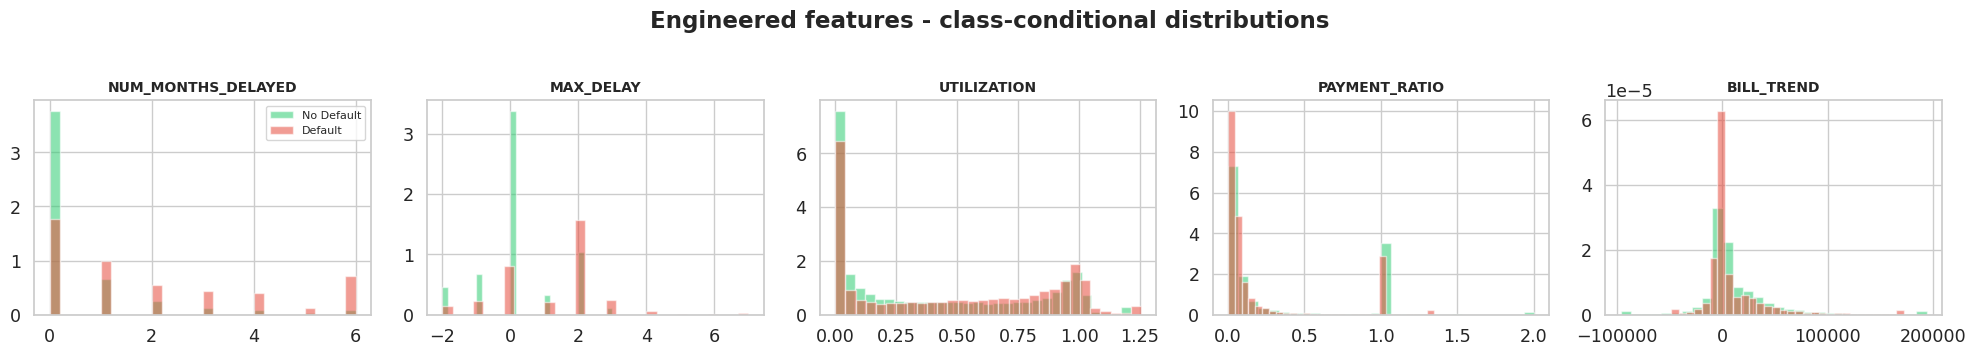

In [12]:
# Feature engineering - row-wise, deterministic, no leakage possible
pay_cols      = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
bill_cols     = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

df['NUM_MONTHS_DELAYED'] = (df[pay_cols] >= 1).sum(axis=1).astype(int)
df['MAX_DELAY']          = df[pay_cols].max(axis=1).astype(int)
df['UTILIZATION']        = df['BILL_AMT1'] / df['LIMIT_BAL'].replace(0, np.nan)
df['UTILIZATION']        = df['UTILIZATION'].fillna(0)

# PAYMENT_RATIO: "how much of last month's bill was actually paid this month".
# BILL_AMT2 can be zero (no bill) or negative (credit balance from prepayment).
# In both cases the ratio is not meaningful, so we fall back to a denominator of 1
# (ratio = amount paid) instead of letting the sign/zero leak into the feature.
safe_bill2 = df['BILL_AMT2'].where(df['BILL_AMT2'] > 0, other=1)
df['PAYMENT_RATIO']      = df['PAY_AMT1'] / safe_bill2
df['BILL_TREND']         = df['BILL_AMT1'] - df['BILL_AMT6']

engineered = ['NUM_MONTHS_DELAYED', 'MAX_DELAY', 'UTILIZATION', 'PAYMENT_RATIO', 'BILL_TREND']

# Quick sanity report - distribution and default-rate split of each new feature
summary_rows = []
for col in engineered:
    s = df[col]
    summary_rows.append({
        'feature':      col,
        'dtype':        str(s.dtype),
        'min':          round(float(s.min()),  3),
        'median':       round(float(s.median()), 3),
        'max':          round(float(s.max()),  3),
        'mean_nondflt': round(float(df.loc[df['DEFAULT'] == 0, col].mean()), 3),
        'mean_dflt':    round(float(df.loc[df['DEFAULT'] == 1, col].mean()), 3),
    })
fe_summary = pd.DataFrame(summary_rows).set_index('feature')
print(f'DataFrame shape after feature engineering: {df.shape}')
print('\nEngineered-feature summary (with per-class means):')
print(fe_summary.to_string())

# Visual check: distribution of each engineered feature by default status
fig, axes = plt.subplots(1, len(engineered), figsize=(4 * len(engineered), 3.5))
for ax, col in zip(axes, engineered):
    for cls, label, colour in [(0, 'No Default', COLOR_NON), (1, 'Default', COLOR_DEF)]:
        data = df.loc[df['DEFAULT'] == cls, col]
        # Clip outliers for visualisation only
        lo, hi = data.quantile(0.01), data.quantile(0.99)
        data = data.clip(lo, hi)
        ax.hist(data, bins=30, alpha=0.55, label=label, color=colour, density=True)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
axes[0].legend(loc='upper right', fontsize=8)
plt.suptitle('Engineered features - class-conditional distributions', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


In [13]:
X = df.drop(columns=['DEFAULT'])
y = df['DEFAULT']

# Stratified split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print('Split shapes:')
print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_val:  ', X_val.shape, 'y_val:  ', y_val.shape)
print('X_test: ', X_test.shape, 'y_test: ', y_test.shape)

print('\nClass distribution by split:')
for name, y_part in [('train', y_train), ('val', y_val), ('test', y_test)]:
    ratio = y_part.mean()
    print(f'{name:>5}: default ratio = {ratio:.2%}')


Split shapes:
X_train: (20975, 28) y_train: (20975,)
X_val:   (4495, 28) y_val:   (4495,)
X_test:  (4495, 28) y_test:  (4495,)

Class distribution by split:
train: default ratio = 22.13%
  val: default ratio = 22.14%
 test: default ratio = 22.11%


In [14]:
# Define categorical-like and numeric features
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
numeric_features = [col for col in X.columns if col not in categorical_features]

# Build leakage-safe preprocessing pipeline
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_features),
        ('cat', categorical_pipeline, categorical_features)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print('Processed matrix shapes:')
print('train:', X_train_processed.shape)
print('val:  ', X_val_processed.shape)
print('test: ', X_test_processed.shape)

# Reference class weights, reported for completeness. The final model handles the
# 3.5:1 imbalance through SMOTE inside an imblearn Pipeline (see Section 5.1), so
# these weights are NOT passed to the classifier.
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
class_weight_balanced = {
    0: len(y_train) / (2 * neg),
    1: len(y_train) / (2 * pos)
}
print('\nReference class_weight (not applied, SMOTE is used instead):', class_weight_balanced)

Processed matrix shapes:
train: (20975, 95)
val:   (4495, 95)
test:  (4495, 95)

Reference class_weight (not applied, SMOTE is used instead): {0: 0.6420656299742867, 1: 2.259750053867701}


In [15]:
# Preprocessing summary (kept in notebook only, no files written)
split_summary_rows = [
    ('random_state', 42),
    ('train_ratio', 0.70),
    ('val_ratio', 0.15),
    ('test_ratio', 0.15),
    ('train_default_ratio', float(y_train.mean())),
    ('val_default_ratio', float(y_val.mean())),
    ('test_default_ratio', float(y_test.mean())),
    ('class_weight_0', class_weight_balanced[0]),
    ('class_weight_1', class_weight_balanced[1])
]

split_summary_df = pd.DataFrame(split_summary_rows, columns=['key', 'value'])
split_summary_df

,key,value
0,random_state,42.000000
1,train_ratio,0.700000
2,val_ratio,0.150000
3,test_ratio,0.150000
4,train_default_ratio,0.221263
5,val_default_ratio,0.221357
6,test_default_ratio,0.221135
7,class_weight_0,0.642066
8,class_weight_1,2.259750


---
# 5. Modeling & Evaluation


In [16]:
# Shorter aliases for the preprocessed matrices used by every model below.
X_train_p = X_train_processed
X_val_p   = X_val_processed
X_test_p  = X_test_processed


---
## 5.1 Handling Class Imbalance with SMOTE

The dataset has a 3.5:1 imbalance (77.88% No Default vs 22.12% Default). Instead of relying
purely on class weights, we apply **SMOTE** (Synthetic Minority Over-sampling TEchnique) to
generate synthetic minority-class samples in the feature space.

**Leakage-safe usage:**
- SMOTE is fit **only on the training set** (after the scaler/one-hot preprocessing).
- The validation and test sets are left untouched so reported metrics reflect the true
  population distribution.
- For cross-validation we wrap SMOTE inside an `imblearn` Pipeline so it is re-fit inside
  each fold, never on held-out data.


Class distribution in TRAINING set
               Before    After SMOTE
No Default     16,334         16,334
Default         4,641         16,334

Total train rows : 20,975 -> 32,668
Default ratio    : 22.13% -> 50.00%


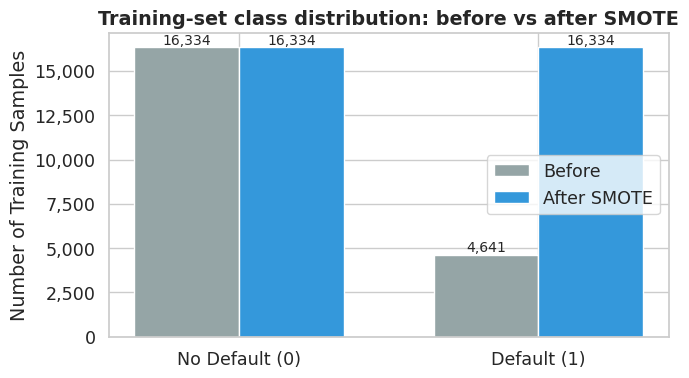

In [17]:
# Apply SMOTE only on the preprocessed training set
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_p, y_train)

before = pd.Series(y_train).value_counts().sort_index()
after  = pd.Series(y_train_sm).value_counts().sort_index()

print('Class distribution in TRAINING set')
print(f'{"":10s} {"Before":>10s} {"After SMOTE":>14s}')
for cls, label in [(0, 'No Default'), (1, 'Default')]:
    print(f'{label:10s} {before[cls]:>10,d} {after[cls]:>14,d}')

print(f'\nTotal train rows : {len(y_train):,} -> {len(y_train_sm):,}')
print(f'Default ratio    : {y_train.mean():.2%} -> {y_train_sm.mean():.2%}')

# Quick bar chart before vs after
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2)
width = 0.35
ax.bar(x - width/2, before.values, width, label='Before', color='#95a5a6')
ax.bar(x + width/2, after.values,  width, label='After SMOTE', color='#3498db')
for i, (b, a) in enumerate(zip(before.values, after.values)):
    ax.text(i - width/2, b + 150, f'{b:,}', ha='center', fontsize=10)
    ax.text(i + width/2, a + 150, f'{a:,}', ha='center', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(['No Default (0)', 'Default (1)'])
ax.set_ylabel('Number of Training Samples')
ax.set_title('Training-set class distribution: before vs after SMOTE', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax.legend()
plt.tight_layout()
plt.show()


---
## 5.2 Why These Metrics?

The dataset has a 78%/22% split, so raw accuracy is misleading -- a model that always
predicts "no default" would score 78% without learning anything.
We report **Weighted F1, AUC-ROC, and Class-1 Recall** as primary metrics throughout.
Class-1 Recall is especially important: in credit risk, missing a real defaulter (False Negative)
is much more costly than a false alarm. Even though SMOTE rebalances the training fold, we
still evaluate on the untouched validation set so the reported metrics reflect the real-world
class distribution.

---
## 5.3 Evaluation Helper

In [18]:
# Unified evaluation function for all models
def evaluate(name, model, X_tr, y_tr, X_ev, y_ev):
    # Train model
    model.fit(X_tr, y_tr)

    # Predictions
    y_pred  = model.predict(X_ev)

    # Probability or decision scores
    y_score = model.predict_proba(X_ev)[:, 1] if hasattr(model, 'predict_proba') \
              else model.decision_function(X_ev)
    # Metrics
    acc      = accuracy_score(y_ev, y_pred)
    f1_w     = f1_score(y_ev, y_pred, average='weighted')
    f1_def   = f1_score(y_ev, y_pred, pos_label=1, average='binary')
    recall_1 = classification_report(y_ev, y_pred, output_dict=True)['1']['recall']
    auc      = roc_auc_score(y_ev, y_score)

    # Print results
    print(f'\n--- {name} ---')
    print(f'Accuracy: {acc:.4f}  |  Weighted F1: {f1_w:.4f}  |  AUC: {auc:.4f}  |  Recall(default): {recall_1:.4f}')
    print(classification_report(y_ev, y_pred, target_names=['No Default', 'Default']))

    # Confusion matrix plot
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix(y_ev, y_pred), display_labels=['No Default', 'Default']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix -- {name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../imgs/cm_{name.replace(" ","_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {
        'Model': name,
        'Accuracy': round(acc, 4),
        'Weighted F1': round(f1_w, 4),
        'F1 (Default)': round(f1_def, 4),
        'Recall (Default)': round(recall_1, 4),
        'AUC-ROC': round(auc, 4),
        '_model': model, '_score': y_score, '_pred': y_pred
    }

print('helper defined.')

helper defined.


---
## 5.4 Logistic Regression (with SMOTE)

Linear baseline. Fast and interpretable.
Instead of `class_weight='balanced'`, the 3.5:1 imbalance is handled by training on the
**SMOTE-resampled** training set produced above.
L2 regularization (`C=1.0`) is important here because the PAY_* columns are correlated with
each other -- Figure 5 showed PAY_0 and PAY_2 have r=0.67. Without regularization,
the model would overfit to a combination of nearly identical features.

Cross-validation is done through an `imblearn` Pipeline (`SMOTE -> LogisticRegression`) so
that SMOTE is re-fit inside each fold and never leaks synthetic samples into held-out data.

CV AUC (SMOTE in-fold): 0.7729 +/- 0.0073

--- Logistic Regression (SMOTE) ---
Accuracy: 0.7533  |  Weighted F1: 0.7644  |  AUC: 0.7654  |  Recall(default): 0.6020
              precision    recall  f1-score   support

  No Default       0.88      0.80      0.83      3500
     Default       0.46      0.60      0.52       995

    accuracy                           0.75      4495
   macro avg       0.67      0.70      0.68      4495
weighted avg       0.78      0.75      0.76      4495



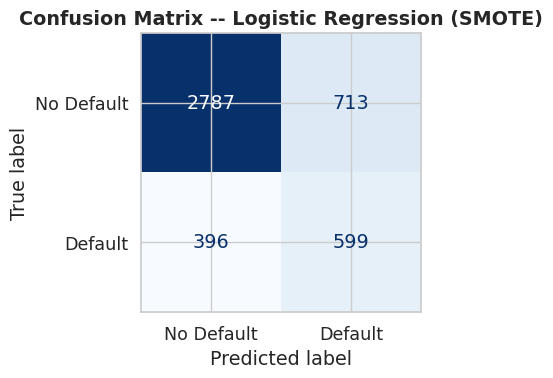

In [19]:
# Logistic Regression trained on the SMOTE-resampled training set.
# Why this model?
# - simple & interpretable
# - strong baseline for binary classification
# - good starting point before complex models
lr = LogisticRegression(
    C=1.0,                       # regularization strength
    max_iter=1000,
    solver='lbfgs',
    random_state=RANDOM_STATE
)

# ----------------------------

# Cross-validation via an imblearn pipeline: SMOTE is refit inside every fold,
# so no synthetic sample ever leaks into the held-out fold used for scoring.
cv_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('clf',   LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=RANDOM_STATE))
])
cv_lr = cross_val_score(
    cv_pipeline, X_train_p, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc'
)
print(f'CV AUC (SMOTE in-fold): {cv_lr.mean():.4f} +/- {cv_lr.std():.4f}')

# ----------------------------

# Validation evaluation: fit on SMOTE-resampled training data, evaluate on the
# untouched validation set so reported metrics reflect the real population.
lr_res = evaluate('Logistic Regression (SMOTE)', lr, X_train_sm, y_train_sm, X_val_p, y_val)

---
## 5.5 Hyperparameter Tuning with an Imbalance-Aware Metric

The default `GridSearchCV(scoring='accuracy')` rewards the majority class on an imbalanced
dataset -- it will happily pick hyperparameters that predict "No Default" more often.
We instead tune on **average precision** (area under the Precision-Recall curve), which
directly reflects how well the model ranks defaulters above non-defaulters and is the
recommended scoring metric for imbalanced binary classification.

The grid is searched through the same SMOTE -> LogisticRegression `imblearn` Pipeline so
SMOTE is re-fit inside every fold (no leakage). We also report `recall` and `f1` of the
best estimator for transparency.


In [20]:
# Leakage-safe grid search: SMOTE inside every CV fold, scoring on the PR-curve area.
# Multi-metric scoring lets us read roc_auc / recall / f1 for the winning config
# straight from `cv_results_` instead of re-running cross_val_score three more times.
search_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('clf',   LogisticRegression(solver='liblinear', max_iter=2000, random_state=RANDOM_STATE))
])

param_grid = {
    'clf__C':       [0.01, 0.1, 1.0, 10.0],
    'clf__penalty': ['l1', 'l2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=search_pipeline,
    param_grid=param_grid,
    scoring={
        'avg_precision': 'average_precision',   # primary - robust to class imbalance
        'roc_auc':       'roc_auc',
        'recall':        'recall',
        'f1':            'f1',
    },
    refit='avg_precision',          # refit the estimator that maximises AUC-PR
    cv=cv,
    n_jobs=-1,
    verbose=0,
)

grid.fit(X_train_p, y_train)

print('Best params          :', grid.best_params_)
print(f'Best CV avg precision: {grid.best_score_:.4f}')

# Pull the secondary CV metrics for the winning config out of cv_results_
best_idx = grid.best_index_
print('\nSecondary CV scores for the winning config:')
for metric in ['roc_auc', 'recall', 'f1']:
    mean = grid.cv_results_[f'mean_test_{metric}'][best_idx]
    std  = grid.cv_results_[f'std_test_{metric}'][best_idx]
    print(f'CV {metric:<8s}: {mean:.4f} +/- {std:.4f}')

# Keep the winning, already-refit estimator around; it is trained on all of X_train_p / y_train
best_model = grid.best_estimator_


Best params          : {'clf__C': 0.1, 'clf__penalty': 'l1'}
Best CV avg precision: 0.5398

Secondary CV scores for the winning config:
CV roc_auc : 0.7732 +/- 0.0069
CV recall  : 0.6115 +/- 0.0085
CV f1      : 0.5370 +/- 0.0051


---
## 5.6 Final Test-Set Evaluation

We evaluate the tuned model on the **untouched held-out test set** at the default
`predict_proba > 0.5` cutoff. The Precision-Recall curve computed on the validation set
is still reported as a diagnostic, together with **AUC-PR** -- it is the most
imbalance-robust single-number summary for a 22% positive class -- but we do **not** use
it to pick a threshold.


Validation average precision (AUC-PR): 0.5488


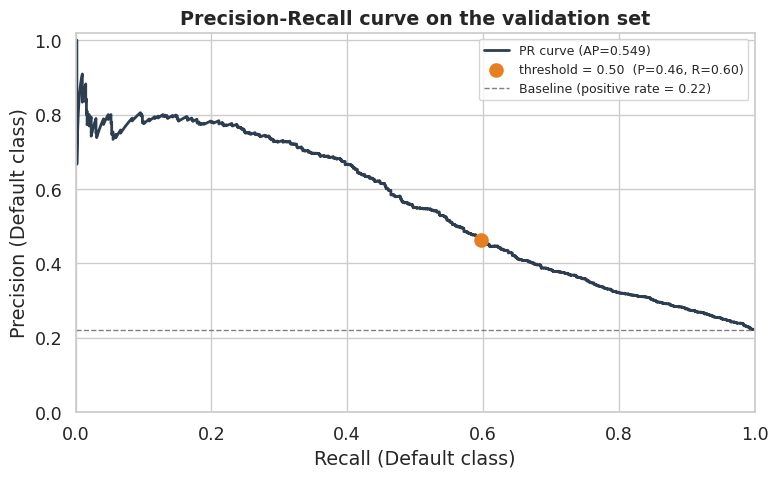

In [21]:
# Diagnostic PR curve on the validation set. We report AUC-PR (the most
# imbalance-robust single-number summary) and mark only the 0.5 cutoff we actually use.
val_scores = best_model.predict_proba(X_val_p)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, val_scores)
ap_val = average_precision_score(y_val, val_scores)
print(f'Validation average precision (AUC-PR): {ap_val:.4f}')

# precision_recall_curve returns N precisions/recalls and N-1 thresholds.
# Align shapes by dropping the final sentinel point (recall=0, precision=1).
p_t, r_t = precision[:-1], recall[:-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(recall, precision, color='#2c3e50', linewidth=2, label=f'PR curve (AP={ap_val:.3f})')

# Mark the default 0.5 operating point for context
i_default = int(np.argmin(np.abs(thresholds - 0.5)))
ax.scatter(r_t[i_default], p_t[i_default], marker='o', color='#e67e22', s=90, zorder=5,
           label=f'threshold = 0.50  (P={p_t[i_default]:.2f}, R={r_t[i_default]:.2f})')

# Baseline = overall default rate in the validation set
ax.axhline(y_val.mean(), color='grey', linestyle='--', linewidth=1,
           label=f'Baseline (positive rate = {y_val.mean():.2f})')

ax.set_xlabel('Recall (Default class)')
ax.set_ylabel('Precision (Default class)')
ax.set_title('Precision-Recall curve on the validation set', fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('../imgs/pr_curve_logreg_smote.png', dpi=150, bbox_inches='tight')
plt.show()



--- Logistic Regression (Tuned, SMOTE) -- Test ---
Accuracy: 0.7666  |  Weighted F1: 0.7762  |  AUC: 0.7704  |  Recall(default): 0.6137
              precision    recall  f1-score   support

  No Default       0.88      0.81      0.84      3501
     Default       0.48      0.61      0.54       994

    accuracy                           0.77      4495
   macro avg       0.68      0.71      0.69      4495
weighted avg       0.79      0.77      0.78      4495



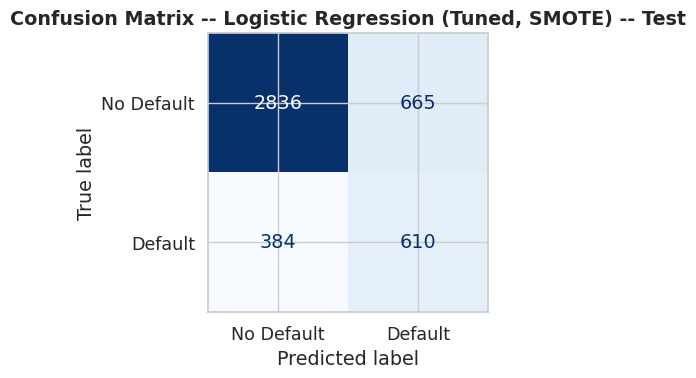

In [22]:
# Final evaluation on the untouched test set at the default 0.5 threshold.
# The evaluate() helper reports Accuracy / Weighted F1 / AUC / Recall(default) plus a
# confusion matrix and the full classification report.
test_res = evaluate('Logistic Regression (Tuned, SMOTE) -- Test',
                    best_model, X_train_p, y_train, X_test_p, y_test)


---
## 5.7 XGBoost

EDA (Figures 2 and 5) showed the payment-history features carry **nonlinear, interacting
signal** that a linear model can only capture through hand-crafted features. Gradient-boosted
trees are a natural next step -- they model interactions and monotonic thresholds directly.

Design choices for this section:

- **XGBoost** (`XGBClassifier`, `tree_method='hist'`) trained on the same preprocessed
  matrix used for Logistic Regression.
- **Imbalance handling** uses XGBoost's native `scale_pos_weight = N_neg / N_pos` (~3.5)
  rather than SMOTE. This is the idiomatic, efficient way to train boosted trees on
  imbalanced data and avoids stacking two imbalance-handling techniques on top of each
  other.
- **Hyperparameters** (`max_depth`, `n_estimators`, `learning_rate`) are selected by
  `GridSearchCV` scored on **average precision**, matching the LR recipe.
- **Final predictions** use the default `predict_proba > 0.5` cutoff, same as LR.

In [23]:
# XGBoost with scale_pos_weight handling the 3.5:1 imbalance natively.
# n_jobs=1 on the classifier so GridSearchCV (n_jobs=-1) parallelises across folds/configs
# without core over-subscription.
scale_pos_weight = int((y_train == 0).sum()) / int((y_train == 1).sum())
print(f'scale_pos_weight = {scale_pos_weight:.3f}')

xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr',
    scale_pos_weight=scale_pos_weight,
    tree_method='hist',
    random_state=RANDOM_STATE,
    n_jobs=1,
)

xgb_param_grid = {
    'max_depth':     [3, 5],
    'n_estimators':  [200, 400],
    'learning_rate': [0.05, 0.1],
}

xgb_grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    scoring={
        'avg_precision': 'average_precision',
        'roc_auc':       'roc_auc',
        'recall':        'recall',
        'f1':            'f1',
    },
    refit='avg_precision',
    cv=cv,
    n_jobs=-1,
    verbose=0,
)

xgb_grid.fit(X_train_p, y_train)

print('Best params          :', xgb_grid.best_params_)
print(f'Best CV avg precision: {xgb_grid.best_score_:.4f}')

best_idx = xgb_grid.best_index_
print('\nSecondary CV scores for the winning config:')
for metric in ['roc_auc', 'recall', 'f1']:
    mean = xgb_grid.cv_results_[f'mean_test_{metric}'][best_idx]
    std  = xgb_grid.cv_results_[f'std_test_{metric}'][best_idx]
    print(f'CV {metric:<8s}: {mean:.4f} +/- {std:.4f}')

best_xgb = xgb_grid.best_estimator_

scale_pos_weight = 3.520
Best params          : {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
Best CV avg precision: 0.5648

Secondary CV scores for the winning config:
CV roc_auc : 0.7829 +/- 0.0081
CV recall  : 0.6393 +/- 0.0135
CV f1      : 0.5338 +/- 0.0101



--- XGBoost (Tuned) ---
Accuracy: 0.7493  |  Weighted F1: 0.7624  |  AUC: 0.7748  |  Recall(default): 0.6281
              precision    recall  f1-score   support

  No Default       0.88      0.78      0.83      3500
     Default       0.45      0.63      0.53       995

    accuracy                           0.75      4495
   macro avg       0.67      0.71      0.68      4495
weighted avg       0.79      0.75      0.76      4495



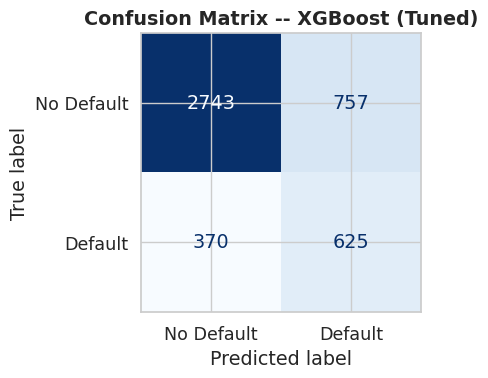


--- XGBoost (Tuned) -- Test ---
Accuracy: 0.7588  |  Weighted F1: 0.7712  |  AUC: 0.7855  |  Recall(default): 0.6439
              precision    recall  f1-score   support

  No Default       0.89      0.79      0.84      3501
     Default       0.47      0.64      0.54       994

    accuracy                           0.76      4495
   macro avg       0.68      0.72      0.69      4495
weighted avg       0.79      0.76      0.77      4495



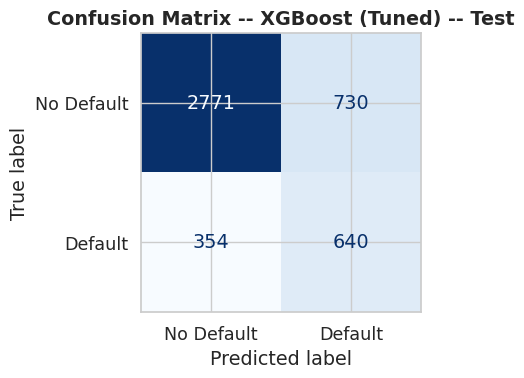

In [24]:
# Validation + test evaluation of the tuned XGBoost at the default 0.5 threshold.
xgb_val_res  = evaluate('XGBoost (Tuned)',
                        best_xgb, X_train_p, y_train, X_val_p,  y_val)
xgb_test_res = evaluate('XGBoost (Tuned) -- Test',
                        best_xgb, X_train_p, y_train, X_test_p, y_test)

---
## 5.8 Results Summary

All metrics are reported at the default `predict_proba > 0.5` cutoff. The validation
rows compare the SMOTE+LR baseline, the grid-tuned LR, and the grid-tuned XGBoost; the
test rows report final out-of-sample performance of each tuned model on the untouched
held-out set. SMOTE, feature engineering, and hyperparameter tuning are all confined to
the training data.

Everything is reproducible with `random_state=42` in SMOTE, the classifiers, and the CV
splitter.



--- Logistic Regression (Tuned, SMOTE) ---
Accuracy: 0.7577  |  Weighted F1: 0.7678  |  AUC: 0.7663  |  Recall(default): 0.5970
              precision    recall  f1-score   support

  No Default       0.88      0.80      0.84      3500
     Default       0.46      0.60      0.52       995

    accuracy                           0.76      4495
   macro avg       0.67      0.70      0.68      4495
weighted avg       0.78      0.76      0.77      4495



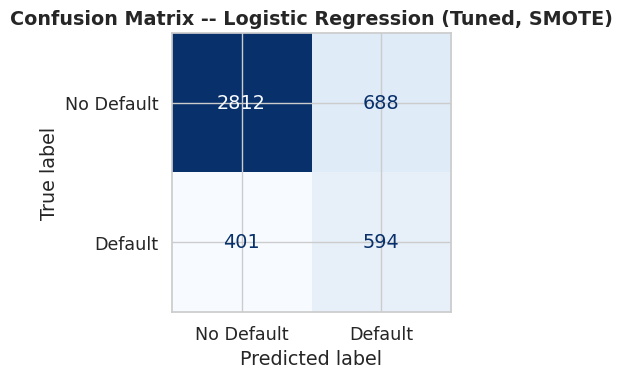

=== Results at the default 0.5 threshold ===
                                                 Split  Accuracy  Weighted F1  F1 (Default)  Recall (Default)  AUC-ROC
Model                                                                                                                 
Logistic Regression (SMOTE)                 Validation    0.7533       0.7644        0.5193            0.6020   0.7654
Logistic Regression (Tuned, SMOTE)          Validation    0.7577       0.7678        0.5217            0.5970   0.7663
Logistic Regression (Tuned, SMOTE) -- Test        Test    0.7666       0.7762        0.5377            0.6137   0.7704
XGBoost (Tuned)                             Validation    0.7493       0.7624        0.5259            0.6281   0.7748
XGBoost (Tuned) -- Test                           Test    0.7588       0.7712        0.5415            0.6439   0.7855


In [25]:
# Evaluate the tuned LR on the validation set using the same helper as the untuned
# baseline, so all models can be compared apples-to-apples.
tuned_res = evaluate('Logistic Regression (Tuned, SMOTE)',
                     best_model, X_train_p, y_train, X_val_p, y_val)

# Consolidated table at the default 0.5 threshold:
#   - LR (SMOTE) baseline on validation
#   - Tuned LR on validation + test
#   - Tuned XGBoost on validation + test
rows    = [lr_res, tuned_res, test_res, xgb_val_res, xgb_test_res]
splits  = ['Validation', 'Validation', 'Test', 'Validation', 'Test']

results_table = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')} for r in rows
]).set_index('Model')
results_table.insert(0, 'Split', splits)

print('=== Results at the default 0.5 threshold ===')
print(results_table.to_string())

---
## 5.9 Models Summary & Comparison

### Logistic Regression (with SMOTE)

The final Logistic Regression model stacks three leakage-safe improvements on top of a
plain linear baseline:

1. **Feature engineering (Section 4a)** -- five row-wise features
   (`NUM_MONTHS_DELAYED`, `MAX_DELAY`, `UTILIZATION`, `PAYMENT_RATIO`, `BILL_TREND`)
   summarise the repayment history and credit-line usage that EDA identified as the
   dominant signal, giving the linear model direct access to non-linear information.
2. **SMOTE (k_neighbors=5)** is applied only to the preprocessed training fold, producing
   a 50/50 training distribution while validation and test keep the natural 22% default
   rate.
3. **Hyperparameters** (`C`, `penalty`) are selected by `GridSearchCV` on an `imblearn`
   Pipeline, scored with **average precision** -- the correct CV metric for imbalanced
   binary classification.

### XGBoost

XGBoost is added as a nonlinear counterpart to the linear baseline:

1. **Trees capture nonlinear interactions natively** -- no hand-crafted features are
   required for the PAY_* / BILL_AMT / LIMIT_BAL interactions that dominate the signal
   (though we still supply them for a fair comparison with LR).
2. **Imbalance handled via `scale_pos_weight`** (~3.5), the idiomatic XGBoost approach.
   This avoids stacking SMOTE on top of a model that already handles the cost asymmetry
   directly through the loss function.
3. **Hyperparameters** (`max_depth`, `n_estimators`, `learning_rate`) are selected by
   `GridSearchCV` scored on **average precision** -- the same imbalance-aware metric
   used for LR.

### Comparison

Both models are evaluated at the default `predict_proba > 0.5` cutoff on the untouched
test set. The consolidated table in Section 5.8 is the primary point of reference; in
general:

- **AUC-ROC / AUC-PR** measure ranking quality regardless of threshold and are the best
  single-number summaries for imbalanced problems.
- **Recall (default)** is the most operationally meaningful metric in credit-risk
  screening, where missing a real defaulter (false negative) is costlier than a false
  alarm.
- **Weighted F1** summarises balanced performance across both classes.

Final predictions are made at the default 0.5 cutoff for both models. The recipe is
entirely reproducible with `random_state=42`.


---
# 6. Conclusion & Submission Notes


## Submission Notes 

- **Problem**: predict next-month credit default risk.
- **Target**: `default payment next month` (binary).
- **Main challenge found**: class imbalance (~22% default class).
- **Data quality**: no missing values in this copy; preprocessing still includes robust imputers.
- **Leakage prevention**: split first, then fit preprocessing only on training set.
- **Imbalance handling strategy**: stratified 70/15/15 split plus **SMOTE** applied only inside the training fold (via an `imblearn` Pipeline, so SMOTE is re-fit inside every CV fold and never leaks into validation or test).
- **Models**: Logistic Regression (with SMOTE) and XGBoost (with `scale_pos_weight`), both tuned by `GridSearchCV` on `average_precision` with final predictions at the default `predict_proba > 0.5` cutoff.

### Final Synthesis

* **Problem & data:** Binary classification of next-month credit default on the UCI Taiwan dataset (30,000 raw rows -> 29,965 unique clients after dropping 35 exact duplicates, 23 features, ~22% default rate, zero missing values).
* **EDA highlights:** PAY_0 is the dominant predictor with a near-monotonic risk gradient; LIMIT_BAL is right-skewed with defaulters holding visibly lower limits; BILL_AMT columns are highly collinear yet weakly related to the target; demographic features contribute only marginal signal.
* **Feature engineering:** Five row-wise features added before the split -- `NUM_MONTHS_DELAYED`, `MAX_DELAY`, `UTILIZATION`, `PAYMENT_RATIO`, `BILL_TREND` -- so the linear model can directly consume the repayment-history and credit-utilisation signals that EDA identified.
* **Preprocessing:** Stratified 70/15/15 split, leakage-safe `ColumnTransformer` (median-impute + StandardScaler for numerics, mode-impute + OneHotEncoder for categorical-like features).
* **Imbalance handling:** SMOTE (k=5) applied **only** to the preprocessed training fold, lifting it from the original 3.5:1 ratio to a balanced 1:1 distribution; validation and test sets are kept at the natural 22% default rate.
* **Modeling:** Two models are compared head-to-head through the same leakage-safe recipe -- **Logistic Regression** (SMOTE inside `imblearn.Pipeline`) and **XGBoost** (native `scale_pos_weight`), both tuned by `GridSearchCV` scored on **average precision** and evaluated on the held-out test set at the default `predict_proba > 0.5` cutoff.
* **Deployment pick:** Whichever of the two tuned models scores higher on the test-set AUC-PR / AUC-ROC (see the consolidated table in Section 5.8), applied at the default 0.5 threshold for the reported metrics.
